[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SushrutGaikwad/svm-gmu/blob/main/examples/demo_2d.ipynb)

# Settings and Imports

In [1]:
!pip install git+https://github.com/SushrutGaikwad/svm-gmu.git

  Cloning https://github.com/SushrutGaikwad/svm-gmu.git to /tmp/pip-req-build-9k7thrm8
  Running command git clone --filter=blob:none --quiet https://github.com/SushrutGaikwad/svm-gmu.git /tmp/pip-req-build-9k7thrm8
  Resolved https://github.com/SushrutGaikwad/svm-gmu.git to commit 54ab23d381d51316560c7bbc75938e3cb768a661
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


You may have to restart the kernel once after this `pip install` command.

In [2]:
import numpy as np
from svm_gmu import (
    SVMGMU,
    validate_gmm_dataset,
    plot_uncertainties,
    plot_decision_boundary,
    plot_comparison,
)
from sklearn.svm import SVC

# Define the data

In [3]:
# --- Class +1 (right side) ---
X_pos = np.array([
    [ 2.0,  3.0],
    [ 2.5,  1.0],
    [ 3.0, -1.0],
    [ 2.0, -3.0],
    [ 1.5,  2.0],
    [ 2.5, -2.0],
])
y_pos = np.ones(len(X_pos), dtype=int)

gmm_pos = [
    {'weights': np.array([0.4, 0.3, 0.3]),
     'means':   np.array([[2.0, 3.0], [1.0, 3.3], [0.2, 2.7]]),
     'covs':    np.array([[[0.05, 0.0], [0.0, 0.05]],
                          [[0.10, 0.03], [0.03, 0.05]],
                          [[0.12, 0.0], [0.0, 0.05]]])},
    {'weights': np.array([0.5, 0.5]),
     'means':   np.array([[2.5, 1.5], [2.5, 0.5]]),
     'covs':    np.array([[[0.04, 0.02], [0.02, 0.06]],
                          [[0.04, -0.02], [-0.02, 0.06]]])},
    {'weights': np.array([0.35, 0.35, 0.3]),
     'means':   np.array([[3.0, -0.7], [3.4, -1.2], [2.6, -1.2]]),
     'covs':    np.array([[[0.04, 0.0], [0.0, 0.03]],
                          [[0.03, 0.01], [0.01, 0.04]],
                          [[0.03, -0.01], [-0.01, 0.04]]])},
    {'weights': np.array([0.3, 0.4, 0.3]),
     'means':   np.array([[2.3, -2.7], [2.0, -3.2], [1.7, -2.7]]),
     'covs':    np.array([[[0.03, -0.02], [-0.02, 0.04]],
                          [[0.05, 0.0], [0.0, 0.02]],
                          [[0.03, 0.02], [0.02, 0.04]]])},
    {'weights': np.array([0.5, 0.5]),
     'means':   np.array([[1.5, 2.0], [0.3, 2.2]]),
     'covs':    np.array([[[0.05, 0.0], [0.0, 0.04]],
                          [[0.15, 0.0], [0.0, 0.04]]])},
    {'weights': np.array([0.4, 0.3, 0.3]),
     'means':   np.array([[2.5, -1.8], [2.2, -2.2], [2.8, -2.2]]),
     'covs':    np.array([[[0.04, 0.0], [0.0, 0.03]],
                          [[0.03, 0.02], [0.02, 0.05]],
                          [[0.03, -0.02], [-0.02, 0.05]]])},
]

# --- Class -1 (left side) ---
X_neg = np.array([
    [-2.0,  3.0],
    [-2.5,  1.0],
    [-2.0, -1.0],
    [-1.5, -3.0],
    [-3.0,  2.0],
    [-2.5, -2.0],
])
y_neg = -np.ones(len(X_neg), dtype=int)

gmm_neg = [
    {'weights': np.array([0.5, 0.5]),
     'means':   np.array([[-2.0, 3.5], [-2.0, 2.5]]),
     'covs':    np.array([[[0.04, -0.02], [-0.02, 0.06]],
                          [[0.04, 0.02], [0.02, 0.06]]])},
    {'weights': np.array([0.35, 0.35, 0.3]),
     'means':   np.array([[-2.5, 1.3], [-2.9, 0.8], [-2.1, 0.8]]),
     'covs':    np.array([[[0.04, 0.0], [0.0, 0.03]],
                          [[0.03, -0.01], [-0.01, 0.04]],
                          [[0.03, 0.01], [0.01, 0.04]]])},
    {'weights': np.array([0.4, 0.3, 0.3]),
     'means':   np.array([[-2.0, -1.0], [-1.0, -1.3], [-0.2, -0.7]]),
     'covs':    np.array([[[0.05, 0.0], [0.0, 0.05]],
                          [[0.10, -0.03], [-0.03, 0.05]],
                          [[0.12, 0.0], [0.0, 0.05]]])},
    {'weights': np.array([0.5, 0.5]),
     'means':   np.array([[-1.5, -3.0], [-0.3, -2.8]]),
     'covs':    np.array([[[0.05, 0.0], [0.0, 0.04]],
                          [[0.15, 0.0], [0.0, 0.04]]])},
    {'weights': np.array([0.3, 0.4, 0.3]),
     'means':   np.array([[-2.7, 2.3], [-3.0, 1.8], [-3.3, 2.3]]),
     'covs':    np.array([[[0.03, 0.02], [0.02, 0.04]],
                          [[0.05, 0.0], [0.0, 0.02]],
                          [[0.03, -0.02], [-0.02, 0.04]]])},
    {'weights': np.array([0.5, 0.5]),
     'means':   np.array([[-2.5, -2.0], [-1.2, -2.2]]),
     'covs':    np.array([[[0.05, 0.0], [0.0, 0.04]],
                          [[0.15, 0.0], [0.0, 0.04]]])},
]

In [4]:
# Combine into one dataset
X = np.vstack([X_pos, X_neg])
y = np.concatenate([y_pos, y_neg])
gmm_params = gmm_pos + gmm_neg

In [5]:
print("X:", end="\n\n")
X

X:



array([[ 2. ,  3. ],
       [ 2.5,  1. ],
       [ 3. , -1. ],
       [ 2. , -3. ],
       [ 1.5,  2. ],
       [ 2.5, -2. ],
       [-2. ,  3. ],
       [-2.5,  1. ],
       [-2. , -1. ],
       [-1.5, -3. ],
       [-3. ,  2. ],
       [-2.5, -2. ]])

In [6]:
print("y:", end="\n\n")
y

y:



array([ 1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1])

In [7]:
print("gmm_params:", end="\n\n")
gmm_params

gmm_params:



[{'weights': array([0.4, 0.3, 0.3]),
  'means': array([[2. , 3. ],
         [1. , 3.3],
         [0.2, 2.7]]),
  'covs': array([[[0.05, 0.  ],
          [0.  , 0.05]],
  
         [[0.1 , 0.03],
          [0.03, 0.05]],
  
         [[0.12, 0.  ],
          [0.  , 0.05]]])},
 {'weights': array([0.5, 0.5]),
  'means': array([[2.5, 1.5],
         [2.5, 0.5]]),
  'covs': array([[[ 0.04,  0.02],
          [ 0.02,  0.06]],
  
         [[ 0.04, -0.02],
          [-0.02,  0.06]]])},
 {'weights': array([0.35, 0.35, 0.3 ]),
  'means': array([[ 3. , -0.7],
         [ 3.4, -1.2],
         [ 2.6, -1.2]]),
  'covs': array([[[ 0.04,  0.  ],
          [ 0.  ,  0.03]],
  
         [[ 0.03,  0.01],
          [ 0.01,  0.04]],
  
         [[ 0.03, -0.01],
          [-0.01,  0.04]]])},
 {'weights': array([0.3, 0.4, 0.3]),
  'means': array([[ 2.3, -2.7],
         [ 2. , -3.2],
         [ 1.7, -2.7]]),
  'covs': array([[[ 0.03, -0.02],
          [-0.02,  0.04]],
  
         [[ 0.05,  0.  ],
          [ 0.  ,

In [8]:
# Validate
validate_gmm_dataset(X, y, gmm_params, verbose=True)

All validations passed!
  Samples: 12, Dimensionality: 2
  Class +1: 6, Class -1: 6
  Point  0 (y=+1): 3 component(s)
  Point  1 (y=+1): 2 component(s)
  Point  2 (y=+1): 3 component(s)
  Point  3 (y=+1): 3 component(s)
  Point  4 (y=+1): 2 component(s)
  Point  5 (y=+1): 3 component(s)
  Point  6 (y=-1): 2 component(s)
  Point  7 (y=-1): 3 component(s)
  Point  8 (y=-1): 3 component(s)
  Point  9 (y=-1): 2 component(s)
  Point 10 (y=-1): 3 component(s)
  Point 11 (y=-1): 2 component(s)


True

# Plot the data with uncertainty contours

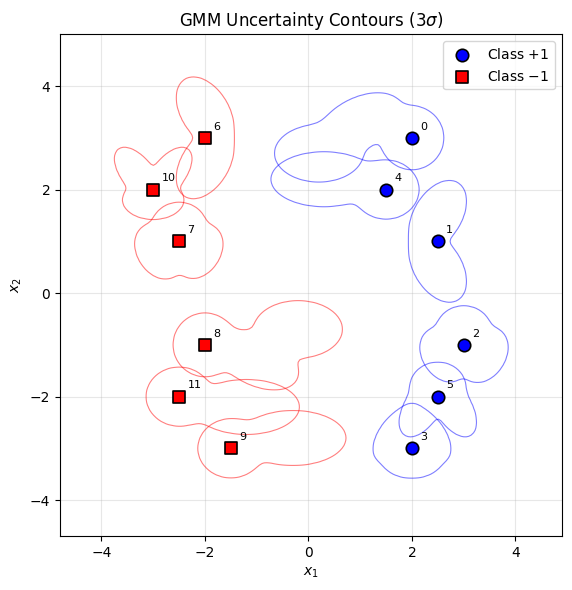

In [9]:
plot_uncertainties(X, y, gmm_params, n_sigma_list=[3]);

# Train the SVM-GMU classifier

In [10]:
clf = SVMGMU(lam=0.01, n_epochs=500, lr_init=0.5, verbose=True)
clf.fit(X, y, gmm_params)

print(f"\nLearned parameters:")
print(f"  w = {clf.w_}")
print(f"  b = {clf.b_:.4f}")
print(f"  Accuracy on X: {clf.score(X, y):.2%}")

  Epoch    0/500: objective = 0.113718, ||w|| = 0.9845, b = 0.0000, lr = 0.500000
  Epoch   50/500: objective = 0.042329, ||w|| = 1.0943, b = -0.0061, lr = 0.009804
  Epoch  100/500: objective = 0.041173, ||w|| = 1.1137, b = -0.0064, lr = 0.004950
  Epoch  150/500: objective = 0.040569, ||w|| = 1.1246, b = -0.0067, lr = 0.003311
  Epoch  200/500: objective = 0.040168, ||w|| = 1.1321, b = -0.0069, lr = 0.002488
  Epoch  250/500: objective = 0.039873, ||w|| = 1.1378, b = -0.0070, lr = 0.001992
  Epoch  300/500: objective = 0.039641, ||w|| = 1.1423, b = -0.0071, lr = 0.001661
  Epoch  350/500: objective = 0.039451, ||w|| = 1.1461, b = -0.0072, lr = 0.001425
  Epoch  400/500: objective = 0.039290, ||w|| = 1.1493, b = -0.0073, lr = 0.001247
  Epoch  450/500: objective = 0.039152, ||w|| = 1.1522, b = -0.0074, lr = 0.001109
  Epoch  499/500: objective = 0.039034, ||w|| = 1.1546, b = -0.0075, lr = 0.001000

Learned parameters:
  w = [1.11011294 0.31746396]
  b = -0.0075
  Accuracy on X: 100.00

# Plot the SVM-GMU decision boundary

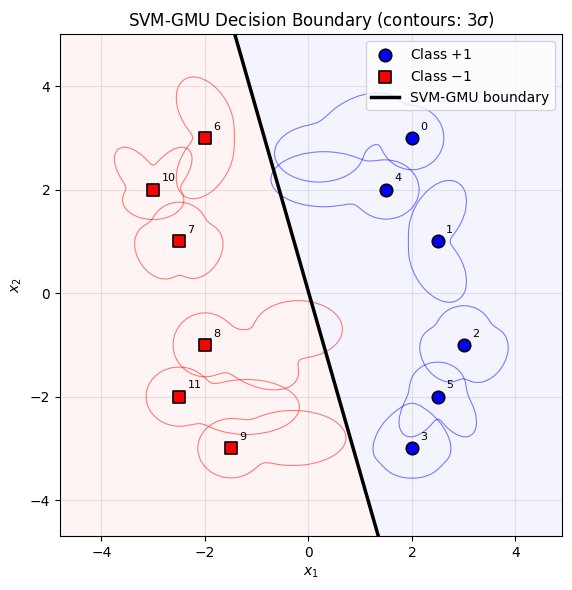

In [11]:
plot_decision_boundary(clf, X, y, gmm_params, n_sigma_list=[3]);

# Compare with standard SVM

In [12]:
# Train a standard SVM that ignores uncertainty
svm_std = SVC(kernel='linear', C=1.0 / 0.01)
svm_std.fit(X, y)

w_std = svm_std.coef_[0]
b_std = svm_std.intercept_[0]

print(f"Standard SVM: w = {w_std}, b = {b_std:.4f}")
print(f"SVM-GMU:      w = {clf.w_}, b = {clf.b_:.4f}")

Standard SVM: w = [0.58533471 0.04867147], b = 0.0244
SVM-GMU:      w = [1.11011294 0.31746396], b = -0.0075


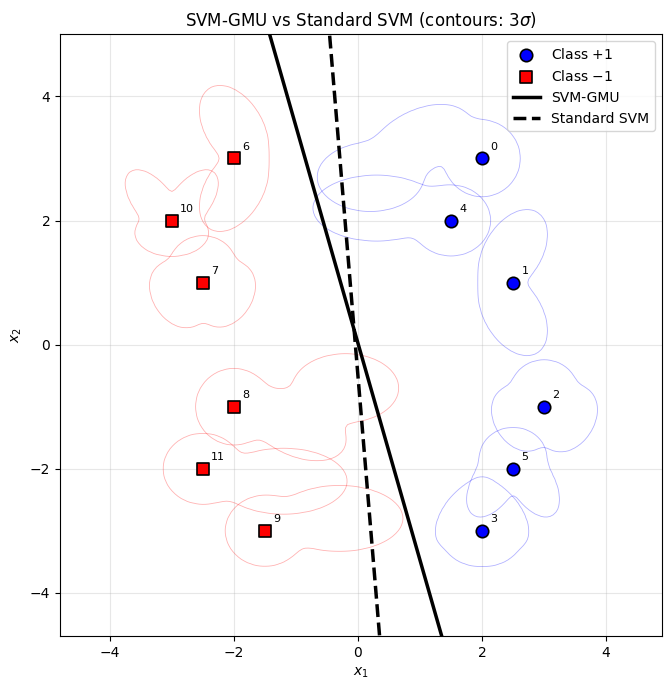

In [13]:
# Plot both boundaries
plot_comparison(clf, w_std, b_std, X, y, gmm_params, n_sigma_list=[3]);

In [14]:
probs_gmu = clf.expected_misclassification(n_mc=50000)
print("Per-point P(misclassification) under SVM-GMU:")
for i in range(len(X)):
    print(f"  Point {i:2d} (y={y[i]:+d}): {probs_gmu[i]:.4f}")
print(f"\nAverage: {np.mean(probs_gmu):.4f}")

Per-point P(misclassification) under SVM-GMU:
  Point  0 (y=+1): 0.0010
  Point  1 (y=+1): 0.0000
  Point  2 (y=+1): 0.0000
  Point  3 (y=+1): 0.0000
  Point  4 (y=+1): 0.0046
  Point  5 (y=+1): 0.0000
  Point  6 (y=-1): 0.0000
  Point  7 (y=-1): 0.0000
  Point  8 (y=-1): 0.0353
  Point  9 (y=-1): 0.0010
  Point 10 (y=-1): 0.0000
  Point 11 (y=-1): 0.0000

Average: 0.0035
